Total Revenue: $2,504,519.14
Average Monthly Spend: $84.48
Churn Rate: 30.20%



/tmp/ipykernel_974/1880575071.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='Support_Calls', palette='Pastel1', ax=axes[1])
/tmp/ipykernel_974/1880575071.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Retained', 'Churned'])


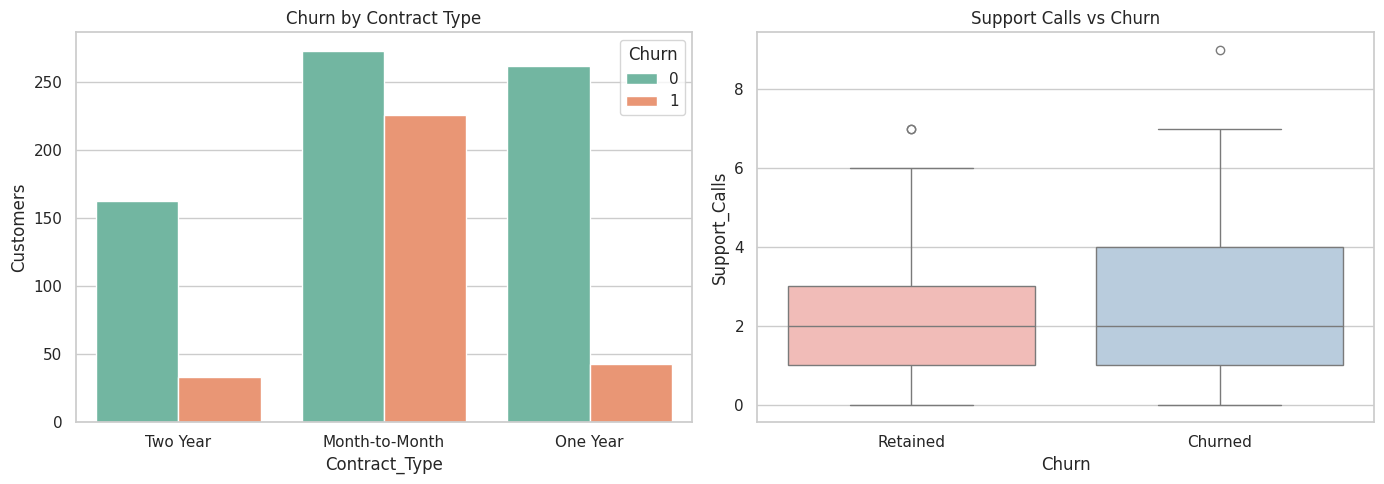

Model Accuracy: 71.50%

              precision    recall  f1-score   support

           0       0.77      0.85      0.81       140
           1       0.53      0.40      0.46        60

    accuracy                           0.71       200
   macro avg       0.65      0.62      0.63       200
weighted avg       0.70      0.71      0.70       200



In [1]:
# ==============================================================================
# AICTE - IBM SkillsBuild Data Analytics with AI Internship Capstone Project
# Author: Anitha Devi Donga
# Topic: Customer Churn & Sales Risk Analytics
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)

# 1. Dataset Generation
np.random.seed(42)
n = 1000

df = pd.DataFrame({
    'CustomerID': [f'CUST_{i:04d}' for i in range(1, n + 1)],
    'Age': np.random.randint(18, 70, size=n),
    'Gender': np.random.choice(['Male', 'Female'], size=n),
    'Tenure_Months': np.random.randint(1, 60, size=n),
    'Monthly_Spend': np.round(np.random.uniform(20.0, 150.0, size=n), 2),
    'Support_Calls': np.random.poisson(lam=2, size=n),
    'Contract_Type': np.random.choice(['Month-to-Month', 'One Year', 'Two Year'], size=n, p=[0.5, 0.3, 0.2]),
    'Region': np.random.choice(['North', 'South', 'East', 'West'], size=n)
})

df['Total_Spend'] = np.round(df['Tenure_Months'] * df['Monthly_Spend'] + np.random.uniform(0, 50, size=n), 2)

# Churn logic
p_churn = (
    0.35 * (df['Contract_Type'] == 'Month-to-Month').astype(int) +
    0.30 * (df['Support_Calls'] > 3).astype(int) +
    0.15 * (df['Monthly_Spend'] > 100).astype(int) -
    0.20 * (df['Tenure_Months'] > 30).astype(int)
)
p_churn = np.clip(p_churn + 0.1, 0, 1)
df['Churn'] = np.random.binomial(1, p_churn)

# 2. KPIs
print(f"Total Revenue: ${df['Total_Spend'].sum():,.2f}")
print(f"Average Monthly Spend: ${df['Monthly_Spend'].mean():.2f}")
print(f"Churn Rate: {df['Churn'].mean() * 100:.2f}%\n")

# 3. Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='Contract_Type', hue='Churn', palette='Set2', ax=axes[0])
axes[0].set_title('Churn by Contract Type')
axes[0].set_ylabel('Customers')

sns.boxplot(data=df, x='Churn', y='Support_Calls', palette='Pastel1', ax=axes[1])
axes[1].set_title('Support Calls vs Churn')
axes[1].set_xticklabels(['Retained', 'Churned'])
plt.tight_layout()
plt.show()

# 4. Machine Learning Model
features = ['Age', 'Tenure_Months', 'Monthly_Spend', 'Support_Calls', 'Contract_Type', 'Gender', 'Region']
X = pd.get_dummies(df[features], drop_first=True)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print(classification_report(y_test, y_pred))